# Definitive Main Results Table: 8 Methods × 8 Datasets with Statistical Tests

**Evaluation of 8 methods (5 FIGS variants + 3 baselines) across 8 Grinsztajn datasets.**

This notebook demonstrates the evaluation pipeline that computes:
- **(A)** 8×8 main results table with balanced_accuracy/r2 mean±std and AUC
- **(B)** Friedman test + Nemenyi post-hoc with critical difference
- **(C)** Bayesian signed-rank tests for key pairwise comparisons
- **(D)** Cohen's d effect sizes for FIGS-vs-baseline pairs
- **(E)** Winner analysis with feature-dimension patterns
- **(F)** Method rankings for all-8 and classification-only-7 datasets
- **(G)** Classification-only Friedman test

The evaluation loads pre-computed per-fold results from experiments, selects best hyperparameters, and runs comprehensive statistical testing.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# scikit-posthocs — NOT on Colab, always install
_pip('scikit-posthocs==0.11.0')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Note: scipy==1.16.3 requires Python >=3.11 (Colab). For local Python 3.10, use scipy==1.15.3.
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', _scipy,
         'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import math
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy.stats import friedmanchisquare, rankdata
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/evaluation_iter6_definitive_main/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded evaluation data: {len(data['metrics_agg'])} aggregate metrics")
print(f"Datasets: {data['metadata']['datasets']}")
print(f"Methods: {data['metadata']['methods']}")
print(f"Example datasets in output: {[d['dataset'] for d in data.get('datasets', [])]}")

Loaded evaluation data: 249 aggregate metrics
Datasets: ['electricity', 'adult', 'california_housing', 'jannis', 'higgs_small', 'eye_movements', 'credit', 'miniboone']
Methods: ['axis_aligned', 'random_oblique', 'unsigned_spectral', 'signed_spectral', 'hard_threshold', 'ebm', 'random_forest', 'linear']
Example datasets in output: ['electricity']


In [5]:
# ─── Config ───────────────────────────────────────────────────────────────
# All tunable parameters from the original evaluation script

FIGS_METHODS = data["metadata"]["figs_methods"]
BASELINE_METHODS = data["metadata"]["baseline_methods"]
ALL_METHODS = data["metadata"]["methods"]
N_METHODS = len(ALL_METHODS)  # 8

DATASETS = data["metadata"]["datasets"]
CLASSIFICATION_DATASETS = data["metadata"]["classification_datasets"]
N_DATASETS = len(DATASETS)  # 8

ALPHA = data["metadata"]["alpha"]    # 0.05 — significance level
ROPE = data["metadata"]["rope"]      # 0.01 — region of practical equivalence

print(f"Config: {N_METHODS} methods × {N_DATASETS} datasets, alpha={ALPHA}, rope={ROPE}")

Config: 8 methods × 8 datasets, alpha=0.05, rope=0.01


## (A) Main Results Table: 8×8 Matrix

Extract the main results table (8 methods × 8 datasets) showing mean±std of the primary metric (balanced_accuracy for classification, r2 for regression) and AUC.

In [6]:
# ─── Metric A: Main Results Table ────────────────────────────────────────
main_table = data["metadata"]["main_results_table"]
print(f"Main results table: {len(main_table)} entries ({N_METHODS} methods × {N_DATASETS} datasets)")

# Build mean matrix: rows=datasets, columns=methods
mean_dict = {}
for entry in main_table:
    ds = entry["dataset"]
    method = entry["method"]
    if ds not in mean_dict:
        mean_dict[ds] = {}
    mean_dict[ds][method] = entry["primary_mean"]

mean_matrix = pd.DataFrame(mean_dict).T
mean_matrix = mean_matrix.reindex(index=DATASETS, columns=ALL_METHODS)
print(f"\nMean performance matrix ({mean_matrix.shape[0]} datasets × {mean_matrix.shape[1]} methods):")
print(mean_matrix.round(4).to_string())

# Display formatted table with mean±std
table_rows = []
for ds in DATASETS:
    row = [ds]
    for method in ALL_METHODS:
        entry = next((e for e in main_table if e["dataset"] == ds and e["method"] == method), None)
        if entry:
            row.append(f"{entry['primary_mean']:.4f}±{entry['primary_std']:.4f}")
        else:
            row.append("—")
    table_rows.append(row)

print(f"\n{'='*120}")
print("Main Results (mean ± std of primary metric):")
print(tabulate(table_rows, headers=["Dataset"] + ALL_METHODS, tablefmt="simple"))

Main results table: 64 entries (8 methods × 8 datasets)

Mean performance matrix (8 datasets × 8 methods):
                    axis_aligned  random_oblique  unsigned_spectral  signed_spectral  hard_threshold     ebm  random_forest  linear
electricity               0.7932          0.7810             0.7912           0.7943          0.7900  0.8441         0.8840  0.7400
adult                     0.6778          0.7076             0.7026           0.7024          0.7029  0.7147         0.7062  0.6716
california_housing        0.6087          0.6908             0.6903           0.6092          0.6807  0.8357         0.8096  0.6014
jannis                    0.7270          0.7337             0.7342           0.7414          0.7422  0.7716         0.7843  0.7289
higgs_small               0.6690          0.6702             0.6756           0.6714          0.6740  0.7150         0.7186  0.6332
eye_movements             0.5890          0.5799             0.5727           0.5815          0.5763 

## (B) Friedman Test + Nemenyi Post-Hoc

The Friedman test checks whether there are statistically significant differences among the methods across all datasets. If significant, Nemenyi post-hoc computes the critical difference (CD) for pairwise comparisons.

In [7]:
# ─── Metric B: Friedman + Nemenyi ────────────────────────────────────────
def compute_nemenyi_cd(n_methods, n_datasets, alpha=0.05):
    """Compute Nemenyi critical difference.
    CD = (q_alpha / sqrt(2)) * sqrt(k*(k+1)/(6*N))
    """
    try:
        from scipy.stats import studentized_range
        q_alpha = studentized_range.ppf(1 - alpha, n_methods, 1e6)
        cd = (q_alpha / np.sqrt(2)) * np.sqrt(
            n_methods * (n_methods + 1) / (6 * n_datasets)
        )
    except Exception:
        # Fallback: manual critical values from Demsar 2006 Table 5, alpha=0.05
        nemenyi_q = {
            3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
            7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164,
        }
        q_val = nemenyi_q.get(n_methods, 3.031)
        cd = q_val * np.sqrt(n_methods * (n_methods + 1) / (6 * n_datasets))
    return cd


def compute_friedman_nemenyi(matrix, label="all"):
    """Friedman test + Nemenyi post-hoc on per-dataset means."""
    n_ds = matrix.shape[0]
    n_meth = matrix.shape[1]

    # Average ranks (higher metric = rank 1 = best)
    ranks = matrix.rank(axis=1, ascending=False)
    avg_ranks = ranks.mean(axis=0)

    # Friedman test
    cols = [matrix[m].values for m in matrix.columns]
    chi2, p_value = friedmanchisquare(*cols)

    # Nemenyi post-hoc pairwise p-values
    nemenyi_pvals_dict = {}
    try:
        nemenyi_result = sp.posthoc_nemenyi_friedman(matrix.values)
        nemenyi_result.index = matrix.columns
        nemenyi_result.columns = matrix.columns
        for i, m1 in enumerate(matrix.columns):
            for j, m2 in enumerate(matrix.columns):
                if i < j:
                    nemenyi_pvals_dict[f"{m1}_vs_{m2}"] = round(
                        float(nemenyi_result.loc[m1, m2]), 6
                    )
    except Exception as e:
        print(f"Nemenyi post-hoc failed: {e}")

    # Nemenyi critical difference
    cd = compute_nemenyi_cd(n_meth, n_ds, ALPHA)

    print(f"\n{'='*60}")
    print(f"Friedman Test ({label}): chi2={chi2:.4f}, p={p_value:.2e}")
    print(f"Significant (p < {ALPHA}): {p_value < ALPHA}")
    print(f"Nemenyi CD: {cd:.4f}")
    print(f"\nAverage Ranks ({label}):")
    for method in sorted(avg_ranks.index, key=lambda m: avg_ranks[m]):
        print(f"  {method:25s}: {avg_ranks[method]:.3f}")

    return {
        "friedman_chi2": round(float(chi2), 6),
        "friedman_pvalue": float(p_value),
        "significant": bool(p_value < ALPHA),
        "avg_ranks": {m: round(float(avg_ranks[m]), 4) for m in matrix.columns},
        "nemenyi_cd": round(float(cd), 4),
        "nemenyi_pairwise_pvalues": nemenyi_pvals_dict,
    }


# Run on all 8 datasets
friedman_all = compute_friedman_nemenyi(mean_matrix, label="all_8")

# Run on classification-only 7 datasets
classif_matrix = mean_matrix.loc[CLASSIFICATION_DATASETS]
friedman_classif = compute_friedman_nemenyi(classif_matrix, label="classif_7")


Friedman Test (all_8): chi2=42.7500, p=3.73e-07
Significant (p < 0.05): True
Nemenyi CD: 3.7121

Average Ranks (all_8):
  ebm                      : 1.500
  random_forest            : 1.625
  unsigned_spectral        : 4.375
  signed_spectral          : 4.625
  hard_threshold           : 4.750
  random_oblique           : 5.000
  axis_aligned             : 6.250
  linear                   : 7.875



Friedman Test (classif_7): chi2=37.0952, p=4.50e-06
Significant (p < 0.05): True
Nemenyi CD: 3.9684

Average Ranks (classif_7):
  ebm                      : 1.571
  random_forest            : 1.571
  unsigned_spectral        : 4.429
  signed_spectral          : 4.429
  hard_threshold           : 4.714
  random_oblique           : 5.286
  axis_aligned             : 6.143
  linear                   : 7.857


## (C) Bayesian Signed-Rank Tests

Display pre-computed Bayesian signed-rank test results for 4 key pairwise comparisons of `unsigned_spectral` vs each baseline/variant. Shows P(left wins), P(equivalent within ROPE), P(right wins).

In [8]:
# ─── Metric C: Bayesian Signed-Rank Tests (pre-computed) ─────────────────
bayesian_tests = data["metadata"]["bayesian_tests"]

print("Bayesian Signed-Rank Tests (ROPE={}):\n".format(ROPE))
bayes_rows = []
for comp_name, comp_data in bayesian_tests.items():
    left, right = comp_name.split("_vs_", 1)
    bayes_rows.append([
        f"{left} vs {right}",
        f"{comp_data['p_left']:.4f}",
        f"{comp_data['p_rope']:.4f}",
        f"{comp_data['p_right']:.4f}",
    ])
print(tabulate(bayes_rows, headers=["Comparison", "P(left>right)", "P(equiv)", "P(right>left)"],
               tablefmt="simple"))

Bayesian Signed-Rank Tests (ROPE=0.01):

Comparison                             P(left>right)    P(equiv)    P(right>left)
-----------------------------------  ---------------  ----------  ---------------
unsigned_spectral vs ebm                      0           0.0024           0.9976
unsigned_spectral vs random_forest            0           0.0059           0.9941
unsigned_spectral vs random_oblique           0.0043      0.9957           0
unsigned_spectral vs axis_aligned             0.5367      0.4629           0.0003


## (D) Cohen's d Effect Sizes

Display pre-computed Cohen's d for all 15 FIGS-vs-baseline pairs (5 FIGS × 3 baselines). Positive d means the FIGS method has better (lower) average rank.

In [9]:
# ─── Metric D: Cohen's d (pre-computed) ──────────────────────────────────
cohens_d = data["metadata"]["cohens_d"]

print("Cohen's d Effect Sizes (FIGS vs Baselines):\n")
cd_rows = []
for pair_name, pair_data in cohens_d.items():
    if pair_data is not None and isinstance(pair_data, dict):
        cd_rows.append([
            pair_name,
            f"{pair_data['cohens_d']:.4f}",
            pair_data["magnitude"],
            f"{pair_data['figs_mean_rank']:.2f}",
            f"{pair_data['baseline_mean_rank']:.2f}",
        ])

print(tabulate(cd_rows,
               headers=["Pair", "Cohen's d", "Magnitude", "FIGS Rank", "Baseline Rank"],
               tablefmt="simple"))

Cohen's d Effect Sizes (FIGS vs Baselines):

Pair                                  Cohen's d  Magnitude      FIGS Rank    Baseline Rank
----------------------------------  -----------  -----------  -----------  ---------------
axis_aligned_vs_ebm                     -3.6692  large               5.92             1.6
axis_aligned_vs_random_forest           -3.1774  large               5.92             1.68
axis_aligned_vs_linear                   1.484   large               5.92             7.72
random_oblique_vs_ebm                   -2.7195  large               5.1              1.6
random_oblique_vs_random_forest         -2.3886  large               5.1              1.68
random_oblique_vs_linear                 1.9911  large               5.1              7.72
unsigned_spectral_vs_ebm                -2.6157  large               4.28             1.6
unsigned_spectral_vs_random_forest      -2.1625  large               4.28             1.68
unsigned_spectral_vs_linear              3.249  

## (E) Winner Analysis & (F) Method Rankings

Per-dataset winner identification and overall method rankings across all 8 datasets and classification-only 7 datasets.

In [10]:
# ─── Metric E: Winner Analysis ──────────────────────────────────────────
winner_analysis = data["metadata"]["winner_analysis"]

print("Per-Dataset Winners:\n")
winner_rows = []
for ds, info in winner_analysis["per_dataset_winners"].items():
    winner_rows.append([ds, info["winner"], f"{info['score']:.4f}"])
print(tabulate(winner_rows, headers=["Dataset", "Winner", "Score"], tablefmt="simple"))

print(f"\nWin Counts:")
for method, count in sorted(winner_analysis["win_counts"].items(), key=lambda x: -x[1]):
    print(f"  {method:25s}: {count}")

# ─── Metric F: Method Rankings ───────────────────────────────────────────
rankings = data["metadata"]["rankings"]

print(f"\n{'='*60}")
print("Method Rankings (all 8 datasets):")
for i, method in enumerate(rankings["all_8_datasets"]["ranking"], 1):
    rank = rankings["all_8_datasets"]["avg_ranks"][method]
    print(f"  #{i}: {method:25s} (avg rank: {rank:.4f})")

print(f"\nMethod Rankings (classification 7 datasets):")
for i, method in enumerate(rankings["classification_7_datasets"]["ranking"], 1):
    rank = rankings["classification_7_datasets"]["avg_ranks"][method]
    print(f"  #{i}: {method:25s} (avg rank: {rank:.4f})")

Per-Dataset Winners:

Dataset             Winner           Score
------------------  -------------  -------
electricity         random_forest   0.884
adult               ebm             0.7147
california_housing  ebm             0.8357
jannis              random_forest   0.7843
higgs_small         random_forest   0.7186
eye_movements       ebm             0.6414
credit              ebm             0.7752
miniboone           random_forest   0.9332

Win Counts:
  random_forest            : 4
  ebm                      : 4
  axis_aligned             : 0
  random_oblique           : 0
  unsigned_spectral        : 0
  signed_spectral          : 0
  hard_threshold           : 0
  linear                   : 0

Method Rankings (all 8 datasets):
  #1: ebm                       (avg rank: 1.5000)
  #2: random_forest             (avg rank: 1.6250)
  #3: unsigned_spectral         (avg rank: 4.3750)
  #4: signed_spectral           (avg rank: 4.6250)
  #5: hard_threshold            (avg rank: 4.7500

## Visualizations

Heatmap of mean performance across all methods and datasets, and a bar chart of average method ranks.

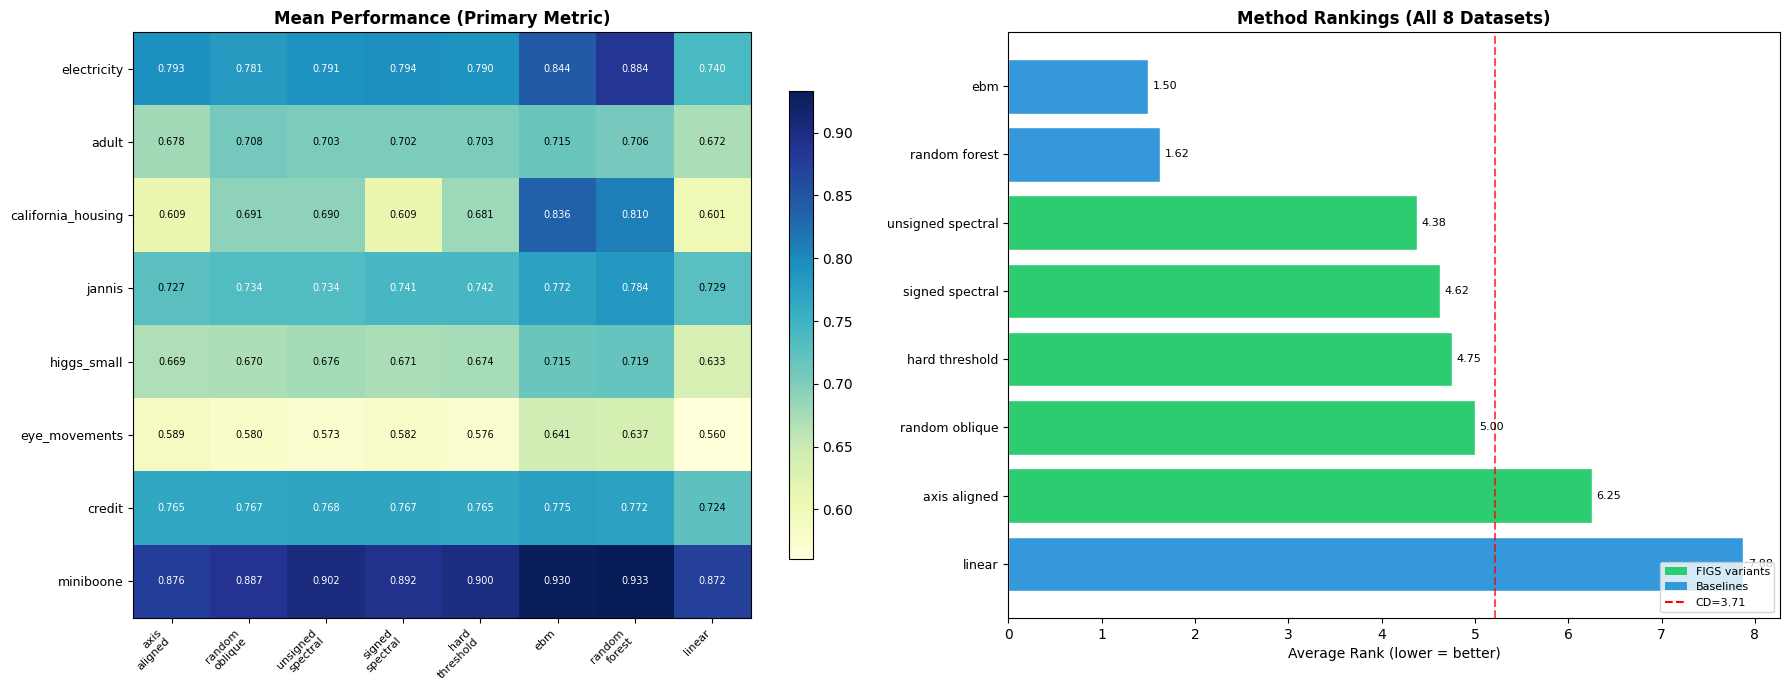

Saved: results_overview.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ─── Plot 1: Performance Heatmap ─────────────────────────────────────────
ax1 = axes[0]
im = ax1.imshow(mean_matrix.values, cmap="YlGnBu", aspect="auto")
ax1.set_xticks(range(len(ALL_METHODS)))
ax1.set_xticklabels([m.replace("_", "\n") for m in ALL_METHODS], rotation=45, ha="right", fontsize=8)
ax1.set_yticks(range(len(DATASETS)))
ax1.set_yticklabels(DATASETS, fontsize=9)
ax1.set_title("Mean Performance (Primary Metric)", fontsize=12, fontweight="bold")

# Annotate cells
for i in range(len(DATASETS)):
    for j in range(len(ALL_METHODS)):
        val = mean_matrix.values[i, j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7,
                     color="white" if val > mean_matrix.values.mean() else "black")

plt.colorbar(im, ax=ax1, shrink=0.8)

# ─── Plot 2: Average Rank Bar Chart ──────────────────────────────────────
ax2 = axes[1]
avg_ranks = friedman_all["avg_ranks"]
methods_sorted = sorted(avg_ranks.keys(), key=lambda m: avg_ranks[m])
ranks_sorted = [avg_ranks[m] for m in methods_sorted]

colors = ["#2ecc71" if m in FIGS_METHODS else "#3498db" if m in BASELINE_METHODS else "#95a5a6"
          for m in methods_sorted]

bars = ax2.barh(range(len(methods_sorted)), ranks_sorted, color=colors, edgecolor="white")
ax2.set_yticks(range(len(methods_sorted)))
ax2.set_yticklabels([m.replace("_", " ") for m in methods_sorted], fontsize=9)
ax2.set_xlabel("Average Rank (lower = better)", fontsize=10)
ax2.set_title("Method Rankings (All 8 Datasets)", fontsize=12, fontweight="bold")
ax2.invert_yaxis()

# Add CD line
cd = friedman_all["nemenyi_cd"]
ax2.axvline(x=ranks_sorted[0] + cd, color="red", linestyle="--", alpha=0.7, label=f"CD={cd:.2f}")
ax2.legend(fontsize=9)

# Add rank values on bars
for i, v in enumerate(ranks_sorted):
    ax2.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=8)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label="FIGS variants"),
                   Patch(facecolor="#3498db", label="Baselines")]
ax2.legend(handles=legend_elements + [plt.Line2D([0], [0], color="red", linestyle="--", label=f"CD={cd:.2f}")],
           fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("results_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_overview.png")